# [LAB 10] 9. 일원분산분석 (2)

In [3]:
from hossam import load_data
from pandas import DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt
# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene
# 분산분석을 위한 라이브러리
from pingouin import anova
from pingouin import welch_anova
# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_tests,pairwise_gameshowell


In [4]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [5]:
origin = load_data('tips')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/tips.xlsx
[desc] 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터 분석·시각화 실습용 샘플 데이터 (출처: https://www.kaggle.com/datasets/sakshisatre/tips-dataset)

field       description
----------  -------------
total_bill  총 결제 금액
tip         팁 금액
sex         성별
smoker      흡연 여부
day         방문 요일
time        방문 시간대
size        일행 규모


===== 데이터 크기 확인 =====
데이터셋 크기: (244, 7)
열 개수: 7
행 개수: 244

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
df = origin[(origin['day'] == 'Fri') | (origin['day'] == 'Sat') |(origin['day'] == 'Sun')]
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


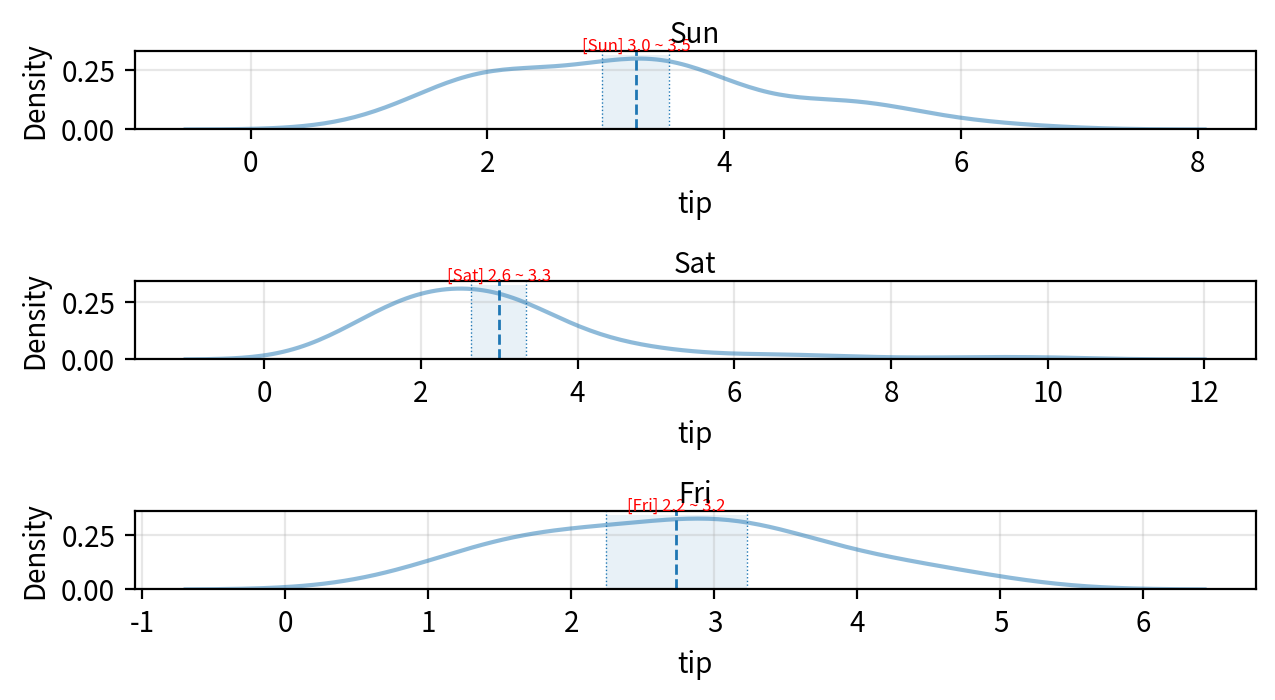

In [13]:
# 확인할 데이터 필드
field = 'tip'
# 집단을 구분하는 필드 (hue)
hue_field = 'day'
# 요일 종류 구하기
hue_values = df[hue_field].unique()
hue_count = len(hue_values)

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = hue_count        # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for i,v in enumerate(hue_values):

    temp = df[df[hue_field] == v]
    #display(temp)
    # KDE Plot 그리기
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])

    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)
    # 신뢰구간
    max = temp[field].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(temp[field]) - 1 # 자유도
    sp_mean = temp[field].mean() # 표본평균
    sp_std = temp[field].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp[field])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
    scale=sp_std_error)
    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
    # 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (v, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() 


In [14]:
# 검사하려는 데이터 추출
groups = [(name, grp['tip']) for name, grp in df.groupby('day')]
report = []
normal_dist = True

for name, series in groups:
    stat, p = normaltest(series)
    ok = p > 0.05
    report.append({"field": name, "statistic": stat, "p-value": p,"result": ok})
    normal_dist = normal_dist and ok

# 등분산성 검정 선택
if normal_dist:
    test_name = "Bartlett"
    stat, p = bartlett(*[s.values for _, s in groups])
else:
    test_name = "Levene"
    stat, p = levene(*[s.values for _, s in groups], center='median')

equal_var = p > 0.05
report.append({"field": test_name, "statistic": stat, "p-value": p,"result": equal_var})
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
Fri,0.416676,8.119325e-01,True
Sat,49.144308,2.130341e-11,False
Sun,3.396232,1.830280e-01,True
Levene,0.651391,5.225516e-01,True


In [15]:
anova_df = origin[['tip', 'day']].copy()
anova_df

,tip,day
0,1.01,Sun
1,1.66,Sun
2,3.50,Sun
3,3.31,Sun
4,3.61,Sun
...,...,...
239,5.92,Sat
240,2.00,Sat
241,2.00,Sat
242,1.75,Sat


In [17]:
if equal_var:
    pg_anova = anova(data=anova_df, dv='tip', between='day')
else:
    pg_anova = welch_anova(data=anova_df, dv='tip', between='day')
pg_anova.T

,0
Source,day
ddof1,3
ddof2,240
F,1.672355
p-unc,0.173589
np2,0.020476


In [18]:
if equal_var:
    print("=== Tukey HSD ===")
    hoc_df = pairwise_tukey(data=anova_df, dv='tip', between='day')
else:
    print("=== Games-Howell ===")
    hoc_df = pairwise_gameshowell(anova_df, dv='tip', between='day')
hoc_df

=== Tukey HSD ===


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,Fri,Sat,2.734737,2.993103,-0.258367,0.348935,-0.740444,0.880645,-0.166274
1,Fri,Sun,2.734737,3.255132,-0.520395,0.353432,-1.472405,0.455805,-0.431509
2,Fri,Thur,2.734737,2.771452,-0.036715,0.361324,-0.101612,0.999623,-0.030468
3,Sat,Sun,2.993103,3.255132,-0.262028,0.216349,-1.211136,0.620382,-0.178644
4,Sat,Thur,2.993103,2.771452,0.221652,0.229016,0.967846,0.767858,0.148857
5,Sun,Thur,3.255132,2.771452,0.483680,0.235811,2.051132,0.172421,0.388762
